# S&P 500 2000~2019 데이터 분석

S&P 500 과거 데이터를 클렌징한 뒤 2000년 초부터 2019년 말까지의 가격 흐름과 연도별·월별 특성을 pandas로 분석합니다.

## 분석 순서

1. CSV 데이터 불러오기 및 구조 확인
2. 날짜와 숫자형 데이터 클렌징
3. 2000~2019년 데이터 필터링
4. 기술통계, 연도별·월별 분석 및 수익률 분석
5. 종가 기준 라인 그래프 작성

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'AppleGothic'
except Exception:
    pass

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

In [2]:
file_path = 'S&P 500 과거 데이터.csv'
raw_df = pd.read_csv(file_path)

print(f'원본 행 수: {len(raw_df):,}')
print(f'원본 열 수: {raw_df.shape[1]}')
display(raw_df.head())
display(raw_df.dtypes.to_frame('자료형'))

원본 행 수: 5,000
원본 열 수: 7


,날짜,종가,시가,고가,저가,거래량,변동 %
0,2019- 11- 14,"3,096.60","3,090.80","3,098.20","3,083.30",NaN,0.08%
1,2019- 11- 13,"3,094.00","3,084.20","3,098.10","3,078.80",NaN,0.07%
2,2019- 11- 12,"3,091.80","3,089.30","3,102.60","3,084.70",NaN,0.16%
3,2019- 11- 11,"3,087.00","3,080.30","3,088.30","3,075.80",NaN,-0.20%
4,2019- 11- 08,"3,093.10","3,081.20","3,093.10","3,073.60",NaN,0.26%


,자료형
날짜,str
종가,str
시가,str
고가,str
저가,str
거래량,float64
변동 %,str


## 1. 데이터 클렌징

날짜의 불필요한 공백을 제거하고, 가격·변동률의 쉼표와 퍼센트 기호를 제거하여 숫자형으로 변환합니다. 거래량처럼 값이 비어 있는 열은 결측치 현황을 확인한 뒤 분석에서 제외할 수 있도록 별도로 보존합니다.

In [3]:
df = raw_df.copy()
df.columns = ['date', 'close', 'open', 'high', 'low', 'volume', 'change_pct']

df['date'] = pd.to_datetime(
    df['date'].astype('string').str.replace(' ', '', regex=False),
    format='%Y-%m-%d',
    errors='coerce'
)

numeric_columns = ['close', 'open', 'high', 'low', 'volume']
for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column].astype('string').str.replace(',', '', regex=False),
        errors='coerce'
    )

df['change_pct'] = pd.to_numeric(
    df['change_pct'].astype('string').str.replace('%', '', regex=False),
    errors='coerce'
)

before_drop = len(df)
df = df.drop_duplicates().dropna(subset=['date', 'close']).copy()
df = df.sort_values('date').reset_index(drop=True)

print(f'중복 및 핵심 결측치 제거 행 수: {before_drop - len(df):,}')
display(df.head())
display(df.isna().sum().to_frame('결측치수'))

중복 및 핵심 결측치 제거 행 수: 0


,date,close,open,high,low,volume,change_pct
0,2000-01-03,"1,455.20","1,469.20","1,478.00","1,438.40",<NA>,-0.95
1,2000-01-04,"1,399.40","1,455.20","1,455.20","1,397.40",<NA>,-3.83
2,2000-01-05,"1,402.10","1,399.40","1,413.30","1,377.70",<NA>,0.19
3,2000-01-06,"1,403.50","1,402.10","1,411.90","1,392.00",<NA>,0.10
4,2000-01-07,"1,441.50","1,403.50","1,441.50","1,400.50",<NA>,2.71


,결측치수
date,0
close,0
open,0
high,0
low,0
volume,5000
change_pct,0


## 2. 2000년 초부터 2019년 말까지 필터링

In [4]:
start_date = pd.Timestamp('2000-01-01')
end_date = pd.Timestamp('2019-12-31')
analysis_df = df[df['date'].between(start_date, end_date)].copy()
analysis_df = analysis_df.set_index('date')
analysis_df['daily_return_pct'] = analysis_df['close'].pct_change().mul(100)

print(f'분석 기간: {analysis_df.index.min().date()} ~ {analysis_df.index.max().date()}')
print(f'분석 데이터 행 수: {len(analysis_df):,}')
display(analysis_df.head())
display(analysis_df.tail())

분석 기간: 2000-01-03 ~ 2019-11-14
분석 데이터 행 수: 5,000


,close,open,high,low,volume,change_pct,daily_return_pct
date,,,,,,,
2000-01-03,"1,455.20","1,469.20","1,478.00","1,438.40",<NA>,-0.95,<NA>
2000-01-04,"1,399.40","1,455.20","1,455.20","1,397.40",<NA>,-3.83,-3.83
2000-01-05,"1,402.10","1,399.40","1,413.30","1,377.70",<NA>,0.19,0.19
2000-01-06,"1,403.50","1,402.10","1,411.90","1,392.00",<NA>,0.10,0.10
2000-01-07,"1,441.50","1,403.50","1,441.50","1,400.50",<NA>,2.71,2.71


,close,open,high,low,volume,change_pct,daily_return_pct
date,,,,,,,
2019-11-08,"3,093.10","3,081.20","3,093.10","3,073.60",<NA>,0.26,0.26
2019-11-11,"3,087.00","3,080.30","3,088.30","3,075.80",<NA>,-0.20,-0.20
2019-11-12,"3,091.80","3,089.30","3,102.60","3,084.70",<NA>,0.16,0.16
2019-11-13,"3,094.00","3,084.20","3,098.10","3,078.80",<NA>,0.07,0.07
2019-11-14,"3,096.60","3,090.80","3,098.20","3,083.30",<NA>,0.08,0.08


## 3. 기본 기술통계

In [5]:
price_summary = analysis_df[['close', 'open', 'high', 'low', 'change_pct']].describe().T
display(price_summary)

print(f"시작 종가: {analysis_df['close'].iloc[0]:,.2f}")
print(f"마지막 종가: {analysis_df['close'].iloc[-1]:,.2f}")
print(f"기간 누적 수익률: {(analysis_df['close'].iloc[-1] / analysis_df['close'].iloc[0] - 1) * 100:.2f}%")
print(f"일간 수익률 변동성(표준편차): {analysis_df['daily_return_pct'].std():.2f}%")

,count,mean,std,min,25%,50%,75%,max
close,"5,000.00","1,565.18",574.25,676.50,"1,150.28","1,358.20","1,973.38","3,096.60"
open,"5,000.00","1,564.99",574.16,679.30,"1,150.45","1,358.05","1,974.28","3,090.80"
high,"5,000.00","1,573.89",574.94,695.30,"1,158.52","1,366.95","1,983.38","3,102.60"
low,"5,000.00","1,555.38",573.24,666.80,"1,140.95","1,347.00","1,965.15","3,084.70"
change_pct,"5,000.00",0.02,1.19,-9.04,-0.47,0.05,0.57,11.59


시작 종가: 1,455.20
마지막 종가: 3,096.60
기간 누적 수익률: 112.80%
일간 수익률 변동성(표준편차): 1.19%


## 4. 연도별 분석

연도별 마지막 종가, 평균 종가, 최고·최저 종가와 연간 수익률을 비교합니다.

,시작종가,마지막종가,평균종가,최고종가,최저종가,거래일수,연간수익률(%)
date,,,,,,,
2000,"1,455.20","1,320.30","1,427.22","1,527.50","1,264.70",252,<NA>
2001,"1,283.30","1,148.10","1,194.18","1,373.70",965.80,248,-13.04
2002,"1,154.70",879.80,993.94,"1,172.50",776.80,252,-23.37
2003,909.00,"1,111.90",965.23,"1,111.90",800.70,252,26.38
2004,"1,108.50","1,211.90","1,130.65","1,213.50","1,063.20",252,8.99
2005,"1,202.10","1,248.30","1,207.23","1,272.70","1,137.50",252,3.00
2006,"1,268.80","1,418.30","1,310.46","1,427.10","1,223.70",251,13.62
2007,"1,416.60","1,468.40","1,477.19","1,565.20","1,374.10",251,3.53
2008,"1,447.20",903.20,"1,220.04","1,447.20",752.40,253,-38.49


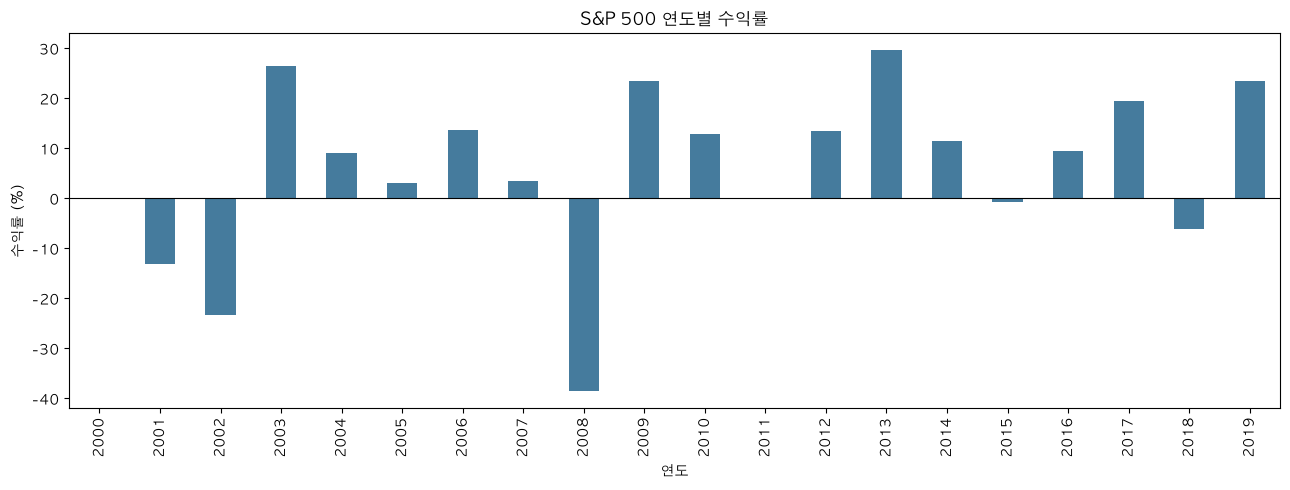

In [6]:
yearly = analysis_df.resample('YE').agg(
    시작종가=('close', 'first'),
    마지막종가=('close', 'last'),
    평균종가=('close', 'mean'),
    최고종가=('close', 'max'),
    최저종가=('close', 'min'),
    거래일수=('close', 'count')
)
yearly['연간수익률(%)'] = yearly['마지막종가'].pct_change().mul(100)
yearly.index = yearly.index.year
display(yearly)

yearly['연간수익률(%)'].plot(kind='bar', figsize=(13, 5), color='#457b9d')
plt.title('S&P 500 연도별 수익률')
plt.xlabel('연도')
plt.ylabel('수익률 (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. 월별 평균 종가와 변동성

,평균종가,월말종가,월간최고,월간최저,일간수익률변동성,월간수익률(%)
date,,,,,,
2000-01-31,"1,425.60","1,394.50","1,478.00","1,350.00",1.67,<NA>
2000-02-29,"1,388.87","1,366.40","1,444.40","1,325.00",1.25,-2.02
2000-03-31,"1,442.22","1,498.60","1,553.10","1,346.50",1.69,9.68
2000-04-30,"1,461.35","1,452.40","1,527.10","1,339.40",2.09,-3.08
2000-05-31,"1,418.48","1,420.60","1,481.40","1,361.20",1.57,-2.19
2000-06-30,"1,461.96","1,454.60","1,489.00","1,420.60",1.05,2.39
2000-07-31,"1,473.00","1,430.80","1,517.20","1,414.20",1.04,-1.64
2000-08-31,"1,485.46","1,517.70","1,525.30","1,426.00",0.64,6.07
2000-09-30,"1,468.05","1,436.50","1,530.00","1,419.50",0.88,-5.35


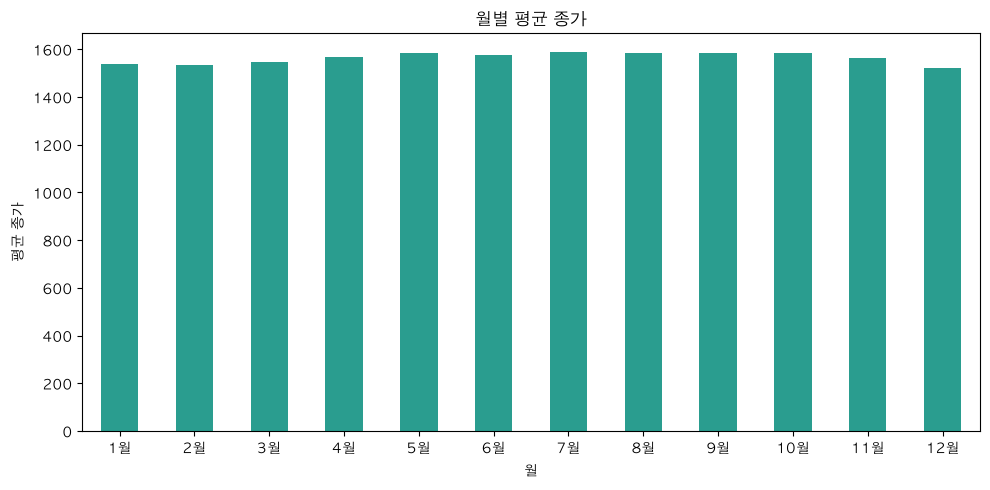

In [7]:
monthly = analysis_df.resample('ME').agg(
    평균종가=('close', 'mean'),
월말종가=('close', 'last'),
월간최고=('high', 'max'),
월간최저=('low', 'min'),
일간수익률변동성=('daily_return_pct', 'std')
)
monthly['월간수익률(%)'] = monthly['월말종가'].pct_change().mul(100)
display(monthly.head(12))

month_average = analysis_df.groupby(analysis_df.index.month)['close'].mean()
month_average.index = [f'{month}월' for month in month_average.index]
month_average.plot(kind='bar', figsize=(10, 5), color='#2a9d8f', rot=0)
plt.title('월별 평균 종가')
plt.xlabel('월')
plt.ylabel('평균 종가')
plt.tight_layout()
plt.show()

## 6. 종가 기준 라인 그래프

2000년부터 2019년까지의 S&P 500 종가 흐름을 선 그래프로 확인합니다.

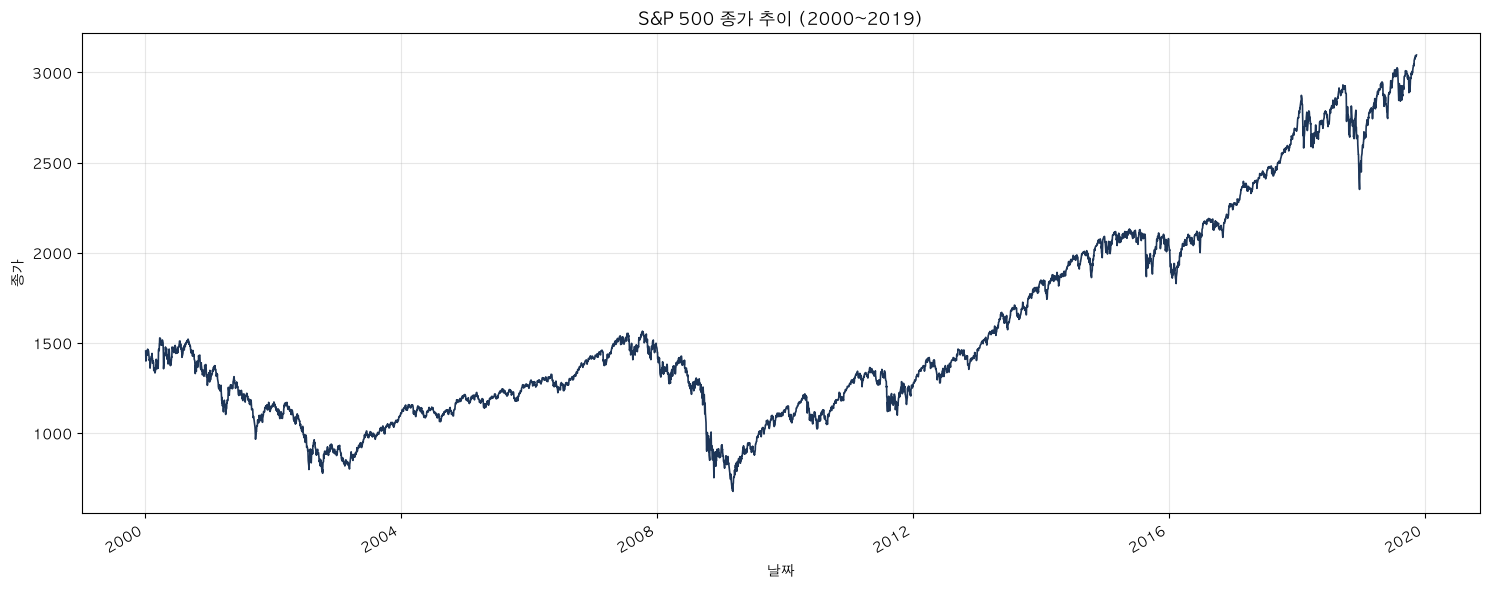

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
analysis_df['close'].plot(ax=ax, color='#1d3557', linewidth=1.2)
ax.set_title('S&P 500 종가 추이 (2000~2019)')
ax.set_xlabel('날짜')
ax.set_ylabel('종가')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 분석 요약

이 노트북은 가격의 관측된 흐름과 통계적 특징을 탐색하기 위한 예제입니다. 연도별 수익률과 변동성은 과거 데이터에 대한 요약이며, 미래 수익을 보장하거나 투자 판단을 대신하지 않습니다.